In [ ]:
# The code used to generate the graphs in figure 1

In [ ]:
#Figure 1A - Residue-level contributors to DSUP pI and buffering capacity

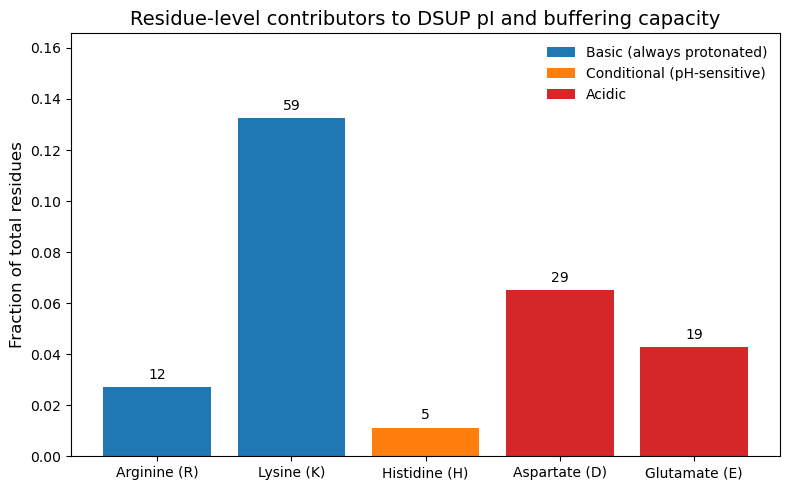

In [2]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1. Input: DSUP amino acid sequence
# -----------------------------
dsup_seq = (
    "MASTHQSSTEPSSTGKSEETKKDASQGSGQDSKNVTVTKGTGSSATSAAIVKTGGSQGKDSSTTAGSSST"
    "QGQKFSTTPTDPKTFSSDQKEKSKSPAKEVPSGGDSKSQGDTKSQSDAKSSGQSQGQSKDSGKSSSDSSK"
    "SHSVIGAVKDVVAGAKDVAGKAVEDAPSIMHTAVDAVKNAATTVKDVASSAASTVAEKVVDAYHSVVGDK"
    "TDDKKEGEHSGDKKDDSKAGSGSGQGGDNKKSEGETSGQAESSSGNEGAAPAKGRGRGRPPAAAKGVAKG"
    "AAKGAAASKGAKSGAESSKGGEQSSGDIEMADASSKGGSDQRDSAATVGEGGASGSEGGAKKGRGRGAGK"
    "KADAGDTSAEPPRRSSRLTSSGTGAGSAPAAAKGGAKRAASSSSTPSNAKKQATGGAGKAAATKATAAKS"
    "AASKAPQNGAGAKKKGGKAGGRKRK"
)

protein = ProteinAnalysis(dsup_seq)

# -----------------------------
# 2. Count amino acids
# -----------------------------
aa_counts = protein.count_amino_acids()
total_length = len(dsup_seq)

# -----------------------------
# 3. Define ionizable residues and their properties
# -----------------------------
# Residue : (label, pKa, charge_type)
ionizable = {
    "R": ("Arginine (R)", 12.5, "basic"),
    "K": ("Lysine (K)", 10.5, "basic"),
    "H": ("Histidine (H)", 6.0, "conditional"),
    "D": ("Aspartate (D)", 3.9, "acidic"),
    "E": ("Glutamate (E)", 4.1, "acidic"),
}

# Extract counts
labels = []
counts = []
fractions = []
pKas = []
types = []

for aa, (label, pKa, charge_type) in ionizable.items():
    labels.append(label)
    count = aa_counts.get(aa, 0)
    counts.append(count)
    fractions.append(count / total_length)
    pKas.append(pKa)
    types.append(charge_type)

# -----------------------------
# 4. Color scheme by chemical role
# -----------------------------
color_map = {
    "basic": "#1f77b4",        # blue 
    "conditional": "#ff7f0e",  # orange
    "acidic": "#d62728",       # red
}

colors = [color_map[t] for t in types]

# -----------------------------
# 5. Plot: residue-level contributors
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(labels, fractions, color=colors)

# Annotate bars with residue counts
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.002,
        f"{count}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# -----------------------------
# 6. Axis labels and title
# -----------------------------
ax.set_ylabel("Fraction of total residues", fontsize=12)
ax.set_title(
    "Residue-level contributors to DSUP pI and buffering capacity",
    fontsize=14
)

ax.set_ylim(0, max(fractions) * 1.25)

# -----------------------------
# 7. Legend (manual, for clarity)
# -----------------------------
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color_map["basic"], label="Basic (always protonated)"),
    Patch(facecolor=color_map["conditional"], label="Conditional (pH-sensitive)"),
    Patch(facecolor=color_map["acidic"], label="Acidic"),
]

ax.legend(handles=legend_elements, frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
#Figure 1B - Charge persistence of DSUP

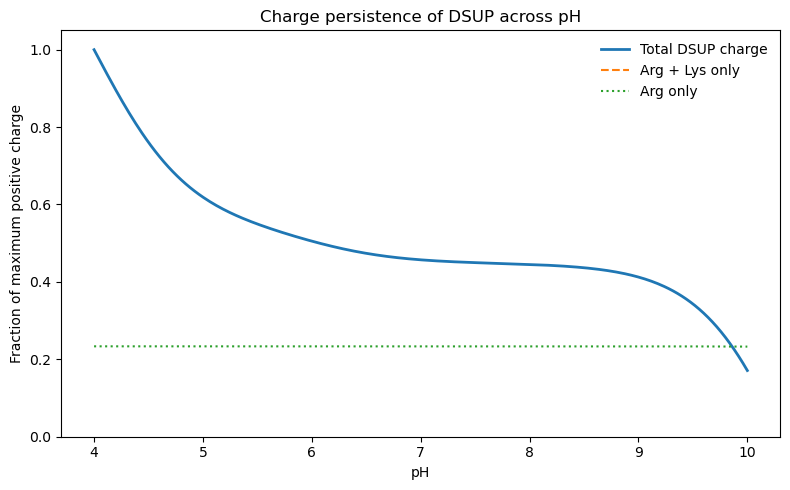

In [3]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Input: DSUP sequence
# -----------------------------
dsup_seq = (
    "MASTHQSSTEPSSTGKSEETKKDASQGSGQDSKNVTVTKGTGSSATSAAIVKTGGSQGKDSSTTAGSSST"
    "QGQKFSTTPTDPKTFSSDQKEKSKSPAKEVPSGGDSKSQGDTKSQSDAKSSGQSQGQSKDSGKSSSDSSK"
    "SHSVIGAVKDVVAGAKDVAGKAVEDAPSIMHTAVDAVKNAATTVKDVASSAASTVAEKVVDAYHSVVGDK"
    "TDDKKEGEHSGDKKDDSKAGSGSGQGGDNKKSEGETSGQAESSSGNEGAAPAKGRGRGRPPAAAKGVAKG"
    "AAKGAAASKGAKSGAESSKGGEQSSGDIEMADASSKGGSDQRDSAATVGEGGASGSEGGAKKGRGRGAGK"
    "KADAGDTSAEPPRRSSRLTSSGTGAGSAPAAAKGGAKRAASSSSTPSNAKKQATGGAGKAAATKATAAKS"
    "AASKAPQNGAGAKKKGGKAGGRKRK"
)


protein = ProteinAnalysis(dsup_seq)
aa_counts = protein.count_amino_acids()

# -----------------------------
# 2. pKa values (canonical)
# -----------------------------
pKa = {
    "R": 12.5,
    "K": 10.5,
    "H": 6.0,
    "D": 3.9,
    "E": 4.1,
}

# -----------------------------
# 3. pH range
# -----------------------------
pH_values = np.linspace(4.0, 10.0, 300)

# -----------------------------
# 4. Charge calculation functions
# -----------------------------
def fraction_protonated_basic(pH, pKa):
    return 1 / (1 + 10**(pH - pKa))

def fraction_deprotonated_acidic(pH, pKa):
    return 1 / (1 + 10**(pKa - pH))

# -----------------------------
# 5. Net charge contributions
# -----------------------------
total_charge = []
arg_charge = []
lys_arg_charge = []

for pH in pH_values:
    charge = 0.0
    charge_R = 0.0
    charge_KR = 0.0

    # Basic residues
    for aa in ["R", "K", "H"]:
        count = aa_counts.get(aa, 0)
        frac = fraction_protonated_basic(pH, pKa[aa])
        contribution = count * frac

        charge += contribution
        if aa == "R":
            charge_R += contribution
        if aa in ["R", "K"]:
            charge_KR += contribution

    # Acidic residues
    for aa in ["D", "E"]:
        count = aa_counts.get(aa, 0)
        frac = fraction_deprotonated_acidic(pH, pKa[aa])
        charge -= count * frac

    total_charge.append(charge)
    arg_charge.append(charge_R)
    lys_arg_charge.append(charge_KR)

# -----------------------------
# 6. Normalize to maximum charge
# -----------------------------
total_charge = np.array(total_charge)
arg_charge = np.array(arg_charge)
lys_arg_charge = np.array(lys_arg_charge)

total_charge_norm = total_charge / np.max(total_charge)
arg_charge_norm = arg_charge / np.max(total_charge)
lys_arg_charge_norm = lys_arg_charge / np.max(total_charge)

# -----------------------------
# 7. Plot
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(pH_values, total_charge_norm, label="Total DSUP charge", linewidth=2)
plt.plot(pH_values, lys_arg_charge_norm, label="Arg + Lys only", linestyle="--")
plt.plot(pH_values, arg_charge_norm, label="Arg only", linestyle=":")

plt.xlabel("pH")
plt.ylabel("Fraction of maximum positive charge")
plt.title("Charge persistence of DSUP across pH")

plt.ylim(0, 1.05)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
#Figure 1C - Electrostatic redundancy of DSUP

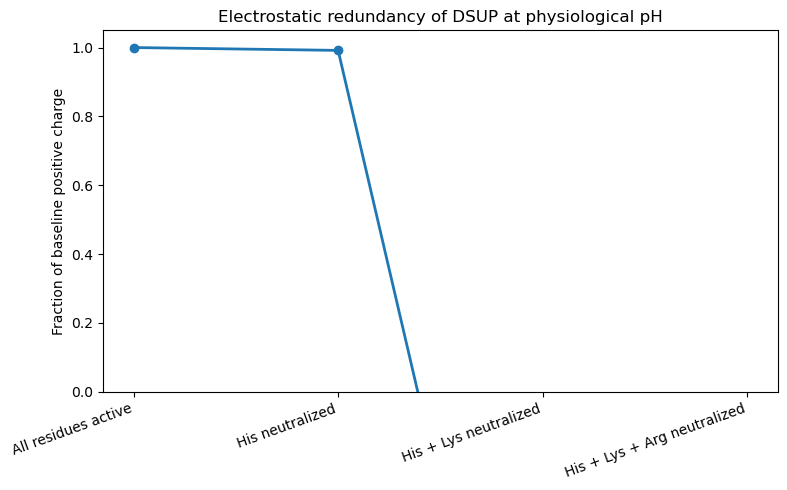

In [4]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Input: DSUP sequence
# -----------------------------
dsup_seq = (
    "MASTHQSSTEPSSTGKSEETKKDASQGSGQDSKNVTVTKGTGSSATSAAIVKTGGSQGKDSSTTAGSSST"
    "QGQKFSTTPTDPKTFSSDQKEKSKSPAKEVPSGGDSKSQGDTKSQSDAKSSGQSQGQSKDSGKSSSDSSK"
    "SHSVIGAVKDVVAGAKDVAGKAVEDAPSIMHTAVDAVKNAATTVKDVASSAASTVAEKVVDAYHSVVGDK"
    "TDDKKEGEHSGDKKDDSKAGSGSGQGGDNKKSEGETSGQAESSSGNEGAAPAKGRGRGRPPAAAKGVAKG"
    "AAKGAAASKGAKSGAESSKGGEQSSGDIEMADASSKGGSDQRDSAATVGEGGASGSEGGAKKGRGRGAGK"
    "KADAGDTSAEPPRRSSRLTSSGTGAGSAPAAAKGGAKRAASSSSTPSNAKKQATGGAGKAAATKATAAKS"
    "AASKAPQNGAGAKKKGGKAGGRKRK"
)

protein = ProteinAnalysis(dsup_seq)
aa_counts = protein.count_amino_acids()

# -----------------------------
# 2. pKa values
# -----------------------------
pKa = {
    "R": 12.5,
    "K": 10.5,
    "H": 6.0,
    "D": 3.9,
    "E": 4.1,
}

# -----------------------------
# 3. Physiological pH
# -----------------------------
pH = 7.4

# -----------------------------
# 4. Charge fraction functions
# -----------------------------
def frac_basic(pH, pKa):
    return 1 / (1 + 10**(pH - pKa))

def frac_acidic(pH, pKa):
    return 1 / (1 + 10**(pKa - pH))

# -----------------------------
# 5. Baseline net charge
# -----------------------------
def compute_net_charge(counts):
    charge = 0.0

    for aa in ["R", "K", "H"]:
        charge += counts.get(aa, 0) * frac_basic(pH, pKa[aa])

    for aa in ["D", "E"]:
        charge -= counts.get(aa, 0) * frac_acidic(pH, pKa[aa])

    return charge

baseline_charge = compute_net_charge(aa_counts)

# -----------------------------
# 6. Progressive neutralization steps
# -----------------------------
steps = [
    {"label": "All residues active", "remove": {}},
    {"label": "His neutralized", "remove": {"H": 1.0}},
    {"label": "His + Lys neutralized", "remove": {"H": 1.0, "K": 1.0}},
    {"label": "His + Lys + Arg neutralized", "remove": {"H": 1.0, "K": 1.0, "R": 1.0}},
]

remaining_charge = []

for step in steps:
    modified_counts = aa_counts.copy()

    for aa, frac_removed in step["remove"].items():
        modified_counts[aa] = aa_counts.get(aa, 0) * (1 - frac_removed)

    charge = compute_net_charge(modified_counts)
    remaining_charge.append(charge / baseline_charge)

# -----------------------------
# 7. Plot
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    range(len(steps)),
    remaining_charge,
    marker="o",
    linewidth=2
)

plt.xticks(
    range(len(steps)),
    [s["label"] for s in steps],
    rotation=20,
    ha="right"
)

plt.ylabel("Fraction of baseline positive charge")
plt.title("Electrostatic redundancy of DSUP at physiological pH")

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [ ]:
#Figure 1D - Net charge of DSUP vs pH

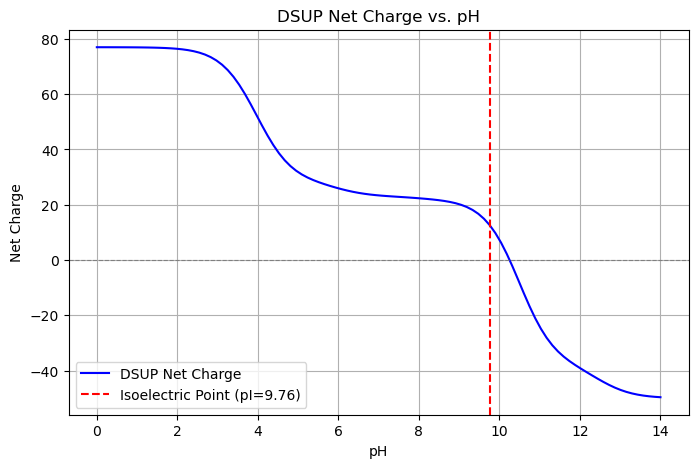

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Bio.SeqUtils import ProtParam

def calculate_charge(sequence, pH_values):
    # Define pKa values for ionizable groups
    pKa_values = {
        'C_term': 3.1, 'D': 3.9, 'E': 4.1, 'H': 6.0, 'C': 8.3, 'Y': 10.1,
        'N_term': 8.0, 'K': 10.5, 'R': 12.5
    }
    
    # Count occurrences of each ionizable residue
    aa_counts = {aa: sequence.count(aa) for aa in pKa_values.keys() if aa in sequence}
    
    net_charges = []
    for pH in pH_values:
        charge = 0
        # Compute charge contribution from N-terminus
        charge += (10**pKa_values['N_term']) / (10**pKa_values['N_term'] + 10**pH)
        # Compute charge contribution from C-terminus
        charge -= (10**pH) / (10**pKa_values['C_term'] + 10**pH)
        
        # Compute charge contribution from amino acids
        for aa, count in aa_counts.items():
            if aa in ['D', 'E', 'C', 'Y']:  # Negatively charged groups
                charge -= count * (10**pH) / (10**pKa_values[aa] + 10**pH)
            elif aa in ['H', 'K', 'R']:  # Positively charged groups
                charge += count * (10**pKa_values[aa]) / (10**pKa_values[aa] + 10**pH)
                
        net_charges.append(charge)
    
    return net_charges

# DSUP protein sequence (provided by user)
dsup_sequence = (
    "MASTHQSSTEPSSTGKSEETKKDASQGSGQDSKNVTVTKGTGSSATSAAIVKTGGSQGKDSSTTAGSSST"
    "QGQKFSTTPTDPKTFSSDQKEKSKSPAKEVPSGGDSKSQGDTKSQSDAKSSGQSQGQSKDSGKSSSDSSK"
    "SHSVIGAVKDVVAGAKDVAGKAVEDAPSIMHTAVDAVKNAATTVKDVASSAASTVAEKVVDAYHSVVGDK"
    "TDDKKEGEHSGDKKDDSKAGSGSGQGGDNKKSEGETSGQAESSSGNEGAAPAKGRGRGRPPAAAKGVAKG"
    "AAKGAAASKGAKSGAESSKGGEQSSGDIEMADASSKGGSDQRDSAATVGEGGASGSEGGAKKGRGRGAGK"
    "KADAGDTSAEPPRRSSRLTSSGTGAGSAPAAAKGGAKRAASSSSTPSNAKKQATGGAGKAAATKATAAKS"
    "AASKAPQNGAGAKKKGGKAGGRKRK"
)

# Define pH range
pH_values = np.linspace(0, 14, 100)

# Calculate net charge across pH values
net_charges = calculate_charge(dsup_sequence, pH_values)

# Plot charge vs. pH
plt.figure(figsize=(8, 5))
plt.plot(pH_values, net_charges, label='DSUP Net Charge', color='b')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(9.76, color='r', linestyle='--', label='Isoelectric Point (pI=9.76)')
plt.xlabel('pH')
plt.ylabel('Net Charge')
plt.title('DSUP Net Charge vs. pH')
plt.legend()
plt.grid()
plt.show()
